In [1]:
!pip install torchdiffeq

  Using cached nvidia_cuda_nvrtc_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_runtime_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cuda_cupti_cu12-12.1.105-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cudnn_cu12-8.9.2.26-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cublas_cu12-12.1.3.1-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cufft_cu12-11.0.2.54-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_curand_cu12-10.3.2.106-py3-none-manylinux1_x86_64.whl.metadata (1.5 kB)
  Using cached nvidia_cusolver_cu12-11.4.5.107-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_cusparse_cu12-12.1.0.106-py3-none-manylinux1_x86_64.whl.metadata (1.6 kB)
  Using cached nvidia_nccl_cu12-2.20.5-py3-none-manylinux2014_x86_64.whl.metadata (1.8 kB)
  Using cached nvidia_nvtx_cu12-12.1.105-py3-none-manylinu

In [2]:
import matplotlib.pyplot as plt
import os
import argparse
import time
import numpy as np
import IPython
import torch
import torch.nn as nn
import torch.optim as optim
import pandas as pd
from torchdiffeq import odeint
from scipy.interpolate import BSpline

In [3]:
import sys
if "google.colab" in sys.modules:
    !wget "https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py"
    import helper
    helper.install_idaes()
    helper.install_ipopt()
    !pyomo build-extensions

--2024-08-12 20:01:56--  https://raw.githubusercontent.com/ndcbe/CBE60499/main/notebooks/helper.py
Resolving raw.githubusercontent.com (raw.githubusercontent.com)... 185.199.108.133, 185.199.110.133, 185.199.111.133, ...
Connecting to raw.githubusercontent.com (raw.githubusercontent.com)|185.199.108.133|:443... connected.
HTTP request sent, awaiting response... 200 OK
Length: 7171 (7.0K) [text/plain]
Saving to: ‘helper.py’

helper.py           100%[===================>]   7.00K  --.-KB/s    in 0s      

2024-08-12 20:01:57 (77.1 MB/s) - ‘helper.py’ saved [7171/7171]

Installing idaes via pip...
idaes was successfully installed
Running idaes get-extensions to install Ipopt, k_aug, and more...
Ipopt 3.13.2 (x86_64-pc-linux-gnu), ASL(20190605)

[K_AUG] 0.1.0, Part of the IDAES PSE framework
Please visit https://idaes.org/ (x86_64-pc-linux-gnu), ASL(20190605)

Couenne 0.5.8 -- an Open-Source solver for Mixed Integer Nonlinear Optimization
Mailing list: couenne@list.coin-or.org
Instructions

In [4]:
import tensorflow.keras as k
from pyomo.environ import *
from pyomo.dae import *

In [5]:
!pip install git+https://github.com/cog-imperial/OMLT.git
#!pip install git+https://github.com/cog-imperial/OMLT.git@notebook-tests-laird

  Cloning https://github.com/cog-imperial/OMLT.git to /tmp/pip-req-build-_yb132bp
  Running command git clone --filter=blob:none --quiet https://github.com/cog-imperial/OMLT.git /tmp/pip-req-build-_yb132bp
  Resolved https://github.com/cog-imperial/OMLT.git to commit e60563859a66ac5dd3348bf1763de57eec95171e
  Installing build dependencies ... done
  Getting requirements to build wheel ... done
  Preparing metadata (pyproject.toml) ... done
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 12.7/12.7 MB 86.6 MB/s eta 0:00:00
  Created wheel for omlt: filename=omlt-1.1.post1.dev121+ge605638-py2.py3-none-any.whl size=54362 sha256=f8260066be410deb6fdf8d878ceaac8eae2342e203dab5f6c845a0802cef8698
  Stored in directory: /tmp/pip-ephem-wheel-cache-7ka4gvg3/wheels/53/93/d9/b409664fba5342c98ad450fa3d16c577f8a9996068e8c513d0
Successfully built omlt
  Attempting uninstall: pyomo
    Found existing installation: Pyomo 6.7.3
    Uninstalling Pyomo-6.7.3:
      Successfully uninstalled Pyomo-6.7.3
ERROR: pi

In [6]:
from omlt import OmltBlock, OffsetScaling
from omlt.neuralnet import FullSpaceNNFormulation, NetworkDefinition,ReluBigMFormulation,ReluComplementarityFormulation,ReducedSpaceNNFormulation
from omlt.io import load_keras_sequential

The class '_BlockData' has been renamed to 'BlockData'.  (deprecated
in 6.7.2)
(called from /usr/local/lib/python3.10/dist-packages/omlt/block.py:33)


In [7]:
m=ConcreteModel()
m.tf=Param(initialize=132)
#m.tf_var=Var(initialize=132,bounds=(72,200))
m.t =ContinuousSet(bounds=(0,m.tf))

mu_max = 0.11
rho_max = 0.0055
Kx = 0.006
Kp = 0.0001
Kin = 0.1
Kdeg = 0.01
Km = 0.0001
mS = 0.029
Yxs = 0.47
Yps = 1.2
Sf = 500


m.U=Var(m.t,initialize=50,bounds=(0,50))
m.V=Var(m.t,bounds=(0,10))
m.X=Var(m.t,bounds=(0,40))
m.P=Var(m.t)
m.S=Var(m.t,bounds=(0,100))

m.mu=Var(m.t)
m.rho=Var(m.t)

m.dVdt = DerivativeVar(m.V,wrt=m.t)
m.dXdt = DerivativeVar(m.X,wrt=m.t)
m.dPdt = DerivativeVar(m.P,wrt=m.t)
m.dSdt = DerivativeVar(m.S,wrt=m.t)

m.obj = Objective(expr=-m.P[m.tf]*m.V[m.tf])

def _x1dot(m,t):
  return m.dVdt[t] == m.U[t]/Sf
m.x1dot=Constraint(m.t, rule=_x1dot)
def _x2dot(m,t):
  return m.dXdt[t] == m.mu[t] * m.X[t] - (m.X[t] / (Sf * m.V[t])) * m.U[t]
m.x2dot=Constraint(m.t, rule=_x2dot)
def _x3dot(m,t):
  return m.dPdt[t] == m.rho[t] * m.X[t] - Kdeg * m.P[t] - (m.P[t] / (Sf * m.V[t])) * m.U[t]
m.x3dot=Constraint(m.t, rule=_x3dot)
def _x4dot(m,t):
  return m.dSdt[t] == -m.mu[t] * (m.X[t] / Yxs) - m.rho[t] * (m.X[t] / Yps) - (mS * m.S[t] / (Km + m.S[t])) * m.X[t] + (1 - m.S[t] / Sf) * (m.U[t] / m.V[t])
m.x4dot=Constraint(m.t, rule=_x4dot)

def _con(m,t):
  return m.mu[t]==mu_max * (m.S[t] / (Kx * m.X[t] + m.S[t]))
m.con = Constraint(m.t,rule=_con)
def _con2(m,t):
  return m.rho[t]==rho_max * (m.S[t] / (Kp + m.S[t] * (1 + m.S[t] / Kin)))
m.con2 = Constraint(m.t,rule=_con2)

def _init(m):
  yield m.V[0]==7
  yield m.P[0]==0
  yield m.S[0]==0
  yield m.X[0]==1.5
m.init_conditions=ConstraintList(rule=_init)

In [8]:
discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(m, nfe=20, ncp=2, scheme='LAGRANGE-RADAU')
#discretizer.reduce_collocation_points(m, var=m.u, ncp=1, contset=m.t)

solver = SolverFactory('ipopt')

results = solver.solve(m, tee=True)

x1_t = []
x2_t = []
x3_t = []
x4_t = []
u_t = []
t_t = []

print(sorted(m.t))

for i in sorted(m.t):
    t_t.append(i)
    x1_t.append(value(m.X[i]))
    x2_t.append(value(m.P[i]))
    x3_t.append(value(m.S[i]))
    x4_t.append(value(m.V[i]))
    u_t.append(value(m.U[i]))

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [10]:
X_train = np.genfromtxt('X_train.csv', delimiter=',')
Y_train = np.genfromtxt('Y_train.csv', delimiter=',')

X_val = np.genfromtxt('X_val.csv', delimiter=',')
Y_val = np.genfromtxt('Y_val.csv', delimiter=',')

In [11]:
df_X = pd.DataFrame(X_train)
df_Y = pd.DataFrame(Y_train)

# Output statistics for each column in the DataFrames
print("Statistics for DataFrame X:")
print(df_X.describe())

print("\nStatistics for DataFrame Y:")
print(df_Y.describe())

Statistics for DataFrame X:
                  0             1             2             3             4
count  80000.000000  80000.000000  80000.000000  80000.000000  80000.000000
mean      20.014831      8.249939      7.501490      7.488677     24.980139
std       11.543787      1.011056      4.328046      4.329214     14.441006
min        0.000200      6.500018      0.000075      0.000225      0.000250
25%       10.022500      7.374239      3.757350      3.735638     12.462625
50%       20.003600      8.247515      7.503750      7.481400     24.969750
75%       30.034300      9.125796     11.243963     11.238713     37.496875
max       39.999800      9.999982     14.999925     14.999925     49.999750

Statistics for DataFrame Y:
                  0             1             2             3
count  80000.000000  8.000000e+04  80000.000000  80000.000000
mean       1.973278  4.996028e-02     -0.117418     -2.015146
std        1.141381  2.888201e-02      0.077249      3.411633
min       -

In [12]:
!pip install pyDOE

  Preparing metadata (setup.py) ... done
  Created wheel for pyDOE: filename=pyDOE-0.3.8-py3-none-any.whl size=18171 sha256=42a1dc91c41c0178684e971248ede46a4e4bf7e05b6e962c3ff4ba3103357d06
  Stored in directory: /root/.cache/pip/wheels/ce/b6/d7/c6b64746dba6433c593e471e0ac3acf4f36040456d1d160d17
Successfully built pyDOE


In [13]:
from pyDOE import lhs

# Define the number of samples and dimensions
num_samples = 80000
num_dimensions = 5
# X V P S U
# Define the upper and lower bounds for each variable
bounds = np.array([[0, 40], [6.5, 10], [0, 15], [0, 15], [0, 50]])

# Generate Latin Hypercube Samples
lhs_samples = lhs(num_dimensions, samples=num_samples, criterion='center')

# Rescale the samples to the specified bounds
scaled_samples = bounds[:, 0] + lhs_samples * (bounds[:, 1] - bounds[:, 0])


In [14]:
#def model_sample(y, t):
#    X1=y[:,1]
#    X2=y[:,2]
#    U=y[:,0]#

#    dX1dt = U
#    dX2dt = X1**2+U**2
#    return np.column_stack((dX1dt,dX2dt))
def model_sample(y, t):
    #X, V, P, S = y
    X=y[:,0]
    V=y[:,1]
    U=y[:,4]
    P=y[:,2]
    S=y[:,3]
    mu_max = 0.11
    rho_max = 0.0055
    Kx = 0.006
    Kp = 0.0001
    Kin = 0.1
    Kdeg = 0.01
    Km = 0.0001
    mS = 0.029
    Yxs = 0.47
    Yps = 1.2
    Sf = 500
    mu = mu_max * (S / (Kx * X + S))
    rho = rho_max * (S / (Kp + S * (1 + S / Kin)))

    dVdt = U / Sf
    dXdt = mu * X - (X / (Sf * V)) * U
    dPdt = rho * X - Kdeg * P - (P / (Sf * V)) * U
    dSdt = -mu * (X / Yxs) - rho * (X / Yps) - (mS * S / (Km + S)) * X + (1 - S / Sf) * (U / V)

    return np.column_stack((dXdt, dVdt, dPdt, dSdt))

In [15]:
y_samp=model_sample(scaled_samples,1)

In [16]:
model_dSdt.evaluate(selected_columns_val, Y_val[:,3].reshape(-1,1))

NameError: name 'model_dSdt' is not defined

In [22]:
from sklearn.model_selection import train_test_split
#checkpoint = k.callbacks.ModelCheckpoint("model_file",monitor="val_loss", mode="min", save_best_only=True, verbose=1)
callback = k.callbacks.EarlyStopping(monitor='val_loss',patience=500,restore_best_weights=True)
X_train, X_val, Y_train, Y_val = train_test_split(scaled_samples, y_samp, test_size=0.2, random_state=42)
model_dSdt=k.Sequential()
model_dSdt.add(k.layers.Dense(20,activation='tanh', input_shape=(4,)))
model_dSdt.add(k.layers.Dense(20,activation='tanh'))
model_dSdt.add(k.layers.Dense(1))

model_dSdt.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model
selected_columns = np.concatenate((X_train[:, 0:2], X_train[:, 3:5]), axis=1)
selected_columns_val = np.concatenate((X_val[:, 0:2], X_val[:, 3:5]), axis=1)
# Train the model
history = model_dSdt.fit(selected_columns, Y_train[:,3].reshape(-1,1), epochs=30, batch_size=32, validation_data=(selected_columns_val, Y_val[:,3].reshape(-1,1)),callbacks=[callback])

Epoch 1/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 1.7901 - val_loss: 0.3095
Epoch 2/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.2501 - val_loss: 0.1600
Epoch 3/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.1301 - val_loss: 0.0707
Epoch 4/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0534 - val_loss: 0.0304
Epoch 5/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0284 - val_loss: 0.0226
Epoch 6/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0178 - val_loss: 0.0160
Epoch 7/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0154 - val_loss: 0.0133
Epoch 8/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0126 - val_loss: 0.0162
Epoch 9/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0114 - val_loss: 0.0195
Epoch 10/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0104 - val_loss: 0.0208
Epoch 11/30
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 0.0089 - val_loss: 0.0110
Epoch 12/30
2000/2000 ━━━━━━━━

In [31]:
history = model_dSdt.fit(selected_columns, Y_train[:,3].reshape(-1,1), epochs=100, batch_size=32, validation_data=(selected_columns_val, Y_val[:,3].reshape(-1,1)),callbacks=[callback])

Epoch 1/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.8197e-04 - val_loss: 0.0012
Epoch 2/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0010 - val_loss: 7.2264e-04
Epoch 3/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0011 - val_loss: 2.8301e-04
Epoch 4/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.0793e-04 - val_loss: 0.0015
Epoch 5/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 9.7620e-04 - val_loss: 8.3934e-04
Epoch 6/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0015 - val_loss: 5.4252e-04
Epoch 7/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 7.9296e-04 - val_loss: 0.0011
Epoch 8/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 6s 2ms/step - loss: 0.0015 - val_loss: 5.4981e-04
Epoch 9/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 0.0011 - val_loss: 0.0012
Epoch 10/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0012 - val_loss: 0.0015
Epoch 11/100
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 0.0012 - 

In [ ]:
model_dVdt=k.Sequential()
model_dVdt.add(k.layers.Dense(10,activation='relu', input_shape=(1,)))
#model.add(k.layers.Dense(50,activation='relu'))
model_dVdt.add(k.layers.Dense(1))

model_dVdt.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model

# Train the model
history = model_dVdt.fit(X_train[:,4].reshape(-1,1), Y_train[:,1].reshape(-1,1), epochs=5, batch_size=32, validation_data=(X_val[:,4].reshape(-1,1), Y_val[:,1].reshape(-1,1)))

In [ ]:
model_dXdt=k.Sequential()
model_dXdt.add(k.layers.Dense(20,activation='relu', input_shape=(4,)))
model_dXdt.add(k.layers.Dense(20,activation='relu'))
model_dXdt.add(k.layers.Dense(1))

model_dXdt.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model
selected_columns = np.concatenate((X_train[:, 0:2], X_train[:, 3:5]), axis=1)
selected_columns_val = np.concatenate((X_val[:, 0:2], X_val[:, 3:5]), axis=1)
# Train the model
history = model_dXdt.fit(selected_columns, Y_train[:,0].reshape(-1,1), epochs=20, batch_size=32, validation_data=(selected_columns_val, Y_val[:,0].reshape(-1,1)))

In [39]:
model_dPdt=k.Sequential()
model_dPdt.add(k.layers.Dense(20,activation='tanh', input_shape=(5,)))
model_dPdt.add(k.layers.Dense(20,activation='tanh'))
model_dPdt.add(k.layers.Dense(1))

model_dPdt.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model
selected_columns = np.concatenate((X_train[:, 0:3], X_train[:, 3:5]), axis=1)
selected_columns_val = np.concatenate((X_val[:, 0:3], X_val[:, 3:5]), axis=1)
# Train the model
history = model_dPdt.fit(selected_columns, Y_train[:,2].reshape(-1,1), epochs=20, batch_size=32, validation_data=(selected_columns_val, Y_val[:,2].reshape(-1,1)))

Epoch 1/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 0.0133 - val_loss: 0.0012
Epoch 2/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 9.7860e-04 - val_loss: 4.8827e-04
Epoch 3/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 4s 2ms/step - loss: 3.3911e-04 - val_loss: 1.2039e-04
Epoch 4/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 1.0517e-04 - val_loss: 1.0424e-04
Epoch 5/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 6.5664e-05 - val_loss: 5.7595e-05
Epoch 6/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 4.5175e-05 - val_loss: 6.4182e-05
Epoch 7/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 3.5232e-05 - val_loss: 2.5678e-05
Epoch 8/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 2ms/step - loss: 2.7973e-05 - val_loss: 2.2807e-05
Epoch 9/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 3s 2ms/step - loss: 2.5521e-05 - val_loss: 1.4855e-05
Epoch 10/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 5s 2ms/step - loss: 1.9531e-05 - val_loss: 1.4646e-05
Epoch 11/20
2000/2000 ━━━━━━━━━━━━━━━━━━━━ 7s 2

In [ ]:
model_dSdt=k.Sequential()
model_dSdt.add(k.layers.Dense(20,activation='tanh', input_shape=(4,)))
model_dSdt.add(k.layers.Dense(20,activation='tanh'))
model_dSdt.add(k.layers.Dense(1))

model_dSdt.compile(optimizer='adam', loss='mean_squared_error')  # Compile the model
selected_columns = np.concatenate((X_train[:, 0:2], X_train[:, 3:5]), axis=1)
selected_columns_val = np.concatenate((X_val[:, 0:2], X_val[:, 3:5]), axis=1)
# Train the model
history = model_dSdt.fit(selected_columns, Y_train[:,3].reshape(-1,1), epochs=20, batch_size=32, validation_data=(selected_columns_val, Y_val[:,3].reshape(-1,1)))

Epoch 1/20
2500/2500 [==============================] - 8s 2ms/step - loss: 0.6864 - val_loss: 0.1626
Epoch 2/20
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0771 - val_loss: 0.0361
Epoch 3/20
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0288 - val_loss: 0.0191
Epoch 4/20
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0195 - val_loss: 0.0168
Epoch 5/20
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0140 - val_loss: 0.0174
Epoch 6/20
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0108 - val_loss: 0.0108
Epoch 7/20
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0089 - val_loss: 0.0054
Epoch 8/20
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0072 - val_loss: 0.0150
Epoch 9/20
2500/2500 [==============================] - 8s 3ms/step - loss: 0.0069 - val_loss: 0.0038
Epoch 10/20
2500/2500 [==============================] - 6s 2ms/step - loss: 0.005

In [ ]:
history = model_dSdt.fit(selected_columns, Y_train[:,3].reshape(-1,1), epochs=100, batch_size=32, validation_data=(selected_columns_val, Y_val[:,3].reshape(-1,1)))

Epoch 1/100
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0026 - val_loss: 0.0019
Epoch 2/100
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0024 - val_loss: 0.0019
Epoch 3/100
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0026 - val_loss: 0.0040
Epoch 4/100
2500/2500 [==============================] - 8s 3ms/step - loss: 0.0029 - val_loss: 0.0048
Epoch 5/100
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0022 - val_loss: 0.0014
Epoch 6/100
2500/2500 [==============================] - 5s 2ms/step - loss: 0.0022 - val_loss: 0.0012
Epoch 7/100
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0021 - val_loss: 0.0012
Epoch 8/100
2500/2500 [==============================] - 6s 2ms/step - loss: 0.0026 - val_loss: 0.0011
Epoch 9/100
2500/2500 [==============================] - 7s 3ms/step - loss: 0.0017 - val_loss: 9.0866e-04
Epoch 10/100
2500/2500 [==============================] - 6s 2ms/step

dP/dt Unknown

In [40]:
def _con_out1(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dPdt[t] == OM.nn[t].m.outputs[0] #dX V P S U


def _con_out2(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dVdt[t] == OM.nn[t].m.outputs[1]  #dx2dt

def _con_out3(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dPdt[t] == OM.nn[t].m.outputs[2] #dx2dt

def _con_out4(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dSdt[t] == OM.nn[t].m.outputs[3] #dx2dt


def _con_in1(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.X[t] == OM.nn[t].m.inputs[0] #x1


def _con_in2(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.V[t] == OM.nn[t].m.inputs[1] #x2


def _con_in3(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.P[t] == OM.nn[t].m.inputs[2]  #u

def _con_in4(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.S[t] == OM.nn[t].m.inputs[3]  #u
def _con_in5(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.U[t] == OM.nn[t].m.inputs[4]  #u

In [41]:
OM=ConcreteModel()
OM.tf=Param(initialize=132)
#m.tf_var=Var(initialize=132,bounds=(72,200))
OM.t =ContinuousSet(bounds=(0,OM.tf))

mu_max = 0.11
rho_max = 0.0055
Kx = 0.006
Kp = 0.0001
Kin = 0.1
Kdeg = 0.01
Km = 0.0001
mS = 0.029
Yxs = 0.47
Yps = 1.2
Sf = 500


OM.U=Var(OM.t,initialize=50,bounds=(0,50))
OM.V=Var(OM.t,bounds=(0,10))
OM.X=Var(OM.t,bounds=(0,40))
OM.P=Var(OM.t,bounds=(0,1e9))
OM.S=Var(OM.t,bounds=(0,100))

OM.mu=Var(OM.t)
OM.rho=Var(OM.t)

OM.dVdt = DerivativeVar(OM.V,wrt=OM.t)
OM.dXdt = DerivativeVar(OM.X,wrt=OM.t)
OM.dPdt = DerivativeVar(OM.P,wrt=OM.t)
OM.dSdt = DerivativeVar(OM.S,wrt=OM.t)

OM.obj = Objective(expr=-OM.P[OM.tf]*OM.V[OM.tf])

def _con(m,t):
  return m.mu[t]==mu_max * (m.S[t] / (Kx * m.X[t] + m.S[t]))
OM.con = Constraint(OM.t,rule=_con)
def _con2(m,t):
  return m.rho[t]==rho_max * (m.S[t] / (Kp + m.S[t] * (1 + m.S[t] / Kin)))
OM.con2 = Constraint(OM.t,rule=_con2)

def _x1dot(m,t):
  return m.dVdt[t] == m.U[t]/Sf
OM.x1dot=Constraint(OM.t, rule=_x1dot)
def _x2dot(m,t):
  return m.dXdt[t] == m.mu[t] * m.X[t] - (m.X[t] / (Sf * m.V[t])) * m.U[t]
OM.x2dot=Constraint(OM.t, rule=_x2dot)
#def _x3dot(m,t):
#  return m.dPdt[t] == m.rho[t] * m.X[t] - Kdeg * m.P[t] - (m.P[t] / (Sf * m.V[t])) * m.U[t]
#OM.x3dot=Constraint(OM.t, rule=_x3dot)
def _x4dot(m,t):
  return m.dSdt[t] == -m.mu[t] * (m.X[t] / Yxs) - m.rho[t] * (m.X[t] / Yps) - (mS * m.S[t] / (Km + m.S[t])) * m.X[t] + (1 - m.S[t] / Sf) * (m.U[t] / m.V[t])
OM.x4dot=Constraint(OM.t, rule=_x4dot)

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(OM, nfe=20, ncp=2, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model_dPdt)
formulation = ReducedSpaceNNFormulation(net)
OM.nn=Block(OM.t)
for t in OM.t:
  OM.nn[t].m=OmltBlock()
  OM.nn[t].m.build_formulation(formulation)

#OM.nn[t].out1=Constraint(OM.t, rule=_con_out1)
#OM.nn[t].out2=Constraint(OM.t, rule=_con_out2)
#OM.nn[t].out3=Constraint(OM.t, rule=_con_out3)
#OM.nn[t].out4=Constraint(OM.t, rule=_con_out4)
#OM.nn[t].in1=Constraint(OM.t, rule=_con_in1)
#OM.nn[t].in2=Constraint(OM.t, rule=_con_in2)
#OM.nn[t].in3=Constraint(OM.t, rule=_con_in3)
#OM.nn[t].in4=Constraint(OM.t, rule=_con_in4)
#OM.nn[t].in5=Constraint(OM.t, rule=_con_in5)
OM.out1=Constraint(OM.t, rule=_con_out1)
#OM.out2=Constraint(OM.t, rule=_con_out2)
#OM.out3=Constraint(OM.t, rule=_con_out3)
#OM.out4=Constraint(OM.t, rule=_con_out4)
OM.in1=Constraint(OM.t, rule=_con_in1)
OM.in2=Constraint(OM.t, rule=_con_in2)
OM.in3=Constraint(OM.t, rule=_con_in3)
OM.in4=Constraint(OM.t, rule=_con_in4)
OM.in5=Constraint(OM.t, rule=_con_in5)

In [42]:
def _init(m):
  yield m.V[0]==7
  yield m.P[0]==0
  yield m.S[0]==0
  yield m.X[0]==1.5
OM.init_conditions=ConstraintList(rule=_init)

#OM.U[0].fix(50.0)

In [43]:
solver = SolverFactory('ipopt')

results = solver.solve(OM, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [44]:
x1 = []
x2 = []
x3 = []
x4 = []
u = []
t = []

print(sorted(OM.t))

for i in sorted(OM.t):
    t.append(i)
    x1.append(value(OM.X[i]))
    x2.append(value(OM.P[i]))
    x3.append(value(OM.S[i]))
    x4.append(value(OM.V[i]))
    u.append(value(OM.U[i]))

[0, 2.2, 6.6, 8.8, 13.2, 15.4, 19.8, 22.0, 26.4, 28.6, 33.0, 35.2, 39.6, 41.8, 46.2, 48.4, 52.8, 55.0, 59.4, 61.6, 66.0, 68.2, 72.6, 74.8, 79.2, 81.4, 85.8, 88.0, 92.4, 94.6, 99.0, 101.2, 105.6, 107.8, 112.2, 114.4, 118.8, 121.0, 125.4, 127.6, 132]


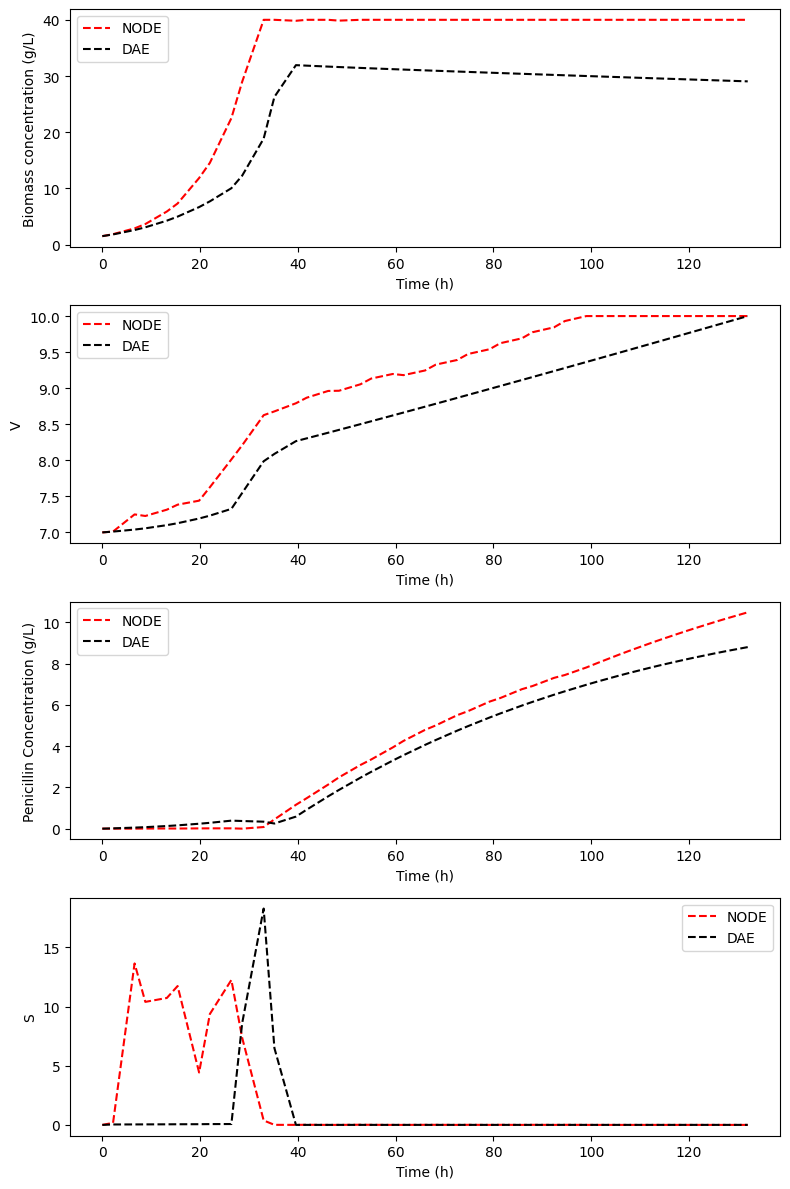

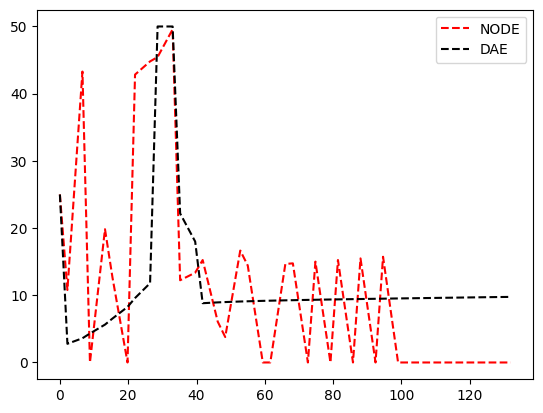

In [46]:
fig, axs = plt.subplots(4, 1, figsize=(8, 12))

# Plot X
axs[0].plot(t, x1,'r--' ,label='NODE')
axs[0].plot(t, x1_t,'k--' ,label='DAE')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('Biomass concentration (g/L)')
axs[0].legend()
#axs[0].set_title('X Profile')

# Plot V
axs[1].plot(t, x4,'r--', label='NODE')
axs[1].plot(t, x4_t,'k--' ,label='DAE')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('V')
axs[1].legend()
#axs[1].set_title('V Profile')

# Plot P
axs[2].plot(t, x2,'r--' ,label='NODE')
axs[2].plot(t, x2_t,'k--' ,label='DAE')
axs[2].set_xlabel('Time (h)')
axs[2].set_ylabel('Penicillin Concentration (g/L)')
axs[2].legend()
#axs[2].set_title('P Profile')

# Plot S
axs[3].plot(t, x3,'r--', label='NODE')
axs[3].plot(t, x3_t,'k--' ,label='DAE')
axs[3].set_xlabel('Time (h)')
axs[3].set_ylabel('S')
axs[3].legend()
plt.savefig('CS3_dP_80k_State.png', dpi=300)
#axs[3].set_title('S Profile')

# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()
plt.plot(t, u,'r--',label='NODE')
plt.plot(t, u_t,'k--' ,label='DAE')
plt.legend()
plt.savefig('CS3_dP_80k_Control.png', dpi=300)
plt.show()

dS/dt Unknown

In [32]:
def _con_out1(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dSdt[t] == OM.nn[t].m.outputs[0] #dX V P S U


def _con_out2(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dVdt[t] == OM.nn[t].m.outputs[1]  #dx2dt

def _con_out3(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dPdt[t] == OM.nn[t].m.outputs[2] #dx2dt

def _con_out4(OM,t):
  if t==0:
    return Constraint.Skip
  return OM.dSdt[t] == OM.nn[t].m.outputs[3] #dx2dt


def _con_in1(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.X[t] == OM.nn[t].m.inputs[0] #x1


def _con_in2(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.V[t] == OM.nn[t].m.inputs[1] #x2


def _con_in3(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.S[t] == OM.nn[t].m.inputs[2]  #u

def _con_in4(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.U[t] == OM.nn[t].m.inputs[3]  #u
def _con_in5(OM,t):
  #if t==0:
   # return Constraint.Skip
  return OM.U[t] == OM.nn[t].m.inputs[4]  #u

In [33]:
OM=ConcreteModel()
OM.tf=Param(initialize=132)
#m.tf_var=Var(initialize=132,bounds=(72,200))
OM.t =ContinuousSet(bounds=(0,OM.tf))

mu_max = 0.11
rho_max = 0.0055
Kx = 0.006
Kp = 0.0001
Kin = 0.1
Kdeg = 0.01
Km = 0.0001
mS = 0.029
Yxs = 0.47
Yps = 1.2
Sf = 500


OM.U=Var(OM.t,initialize=50,bounds=(0,50))
OM.V=Var(OM.t,bounds=(0,10))
OM.X=Var(OM.t,bounds=(0,40))
OM.P=Var(OM.t,bounds=(0,1e9))
OM.S=Var(OM.t,bounds=(0,100))

OM.mu=Var(OM.t)
OM.rho=Var(OM.t)

OM.dVdt = DerivativeVar(OM.V,wrt=OM.t)
OM.dXdt = DerivativeVar(OM.X,wrt=OM.t)
OM.dPdt = DerivativeVar(OM.P,wrt=OM.t)
OM.dSdt = DerivativeVar(OM.S,wrt=OM.t)

OM.obj = Objective(expr=-OM.P[OM.tf]*OM.V[OM.tf])

def _con(m,t):
  return m.mu[t]==mu_max * (m.S[t] / (Kx * m.X[t] + m.S[t]))
OM.con = Constraint(OM.t,rule=_con)
def _con2(m,t):
  return m.rho[t]==rho_max * (m.S[t] / (Kp + m.S[t] * (1 + m.S[t] / Kin)))
OM.con2 = Constraint(OM.t,rule=_con2)

def _x1dot(m,t):
  return m.dVdt[t] == m.U[t]/Sf
OM.x1dot=Constraint(OM.t, rule=_x1dot)
def _x2dot(m,t):
  return m.dXdt[t] == m.mu[t] * m.X[t] - (m.X[t] / (Sf * m.V[t])) * m.U[t]
OM.x2dot=Constraint(OM.t, rule=_x2dot)
def _x3dot(m,t):
  return m.dPdt[t] == m.rho[t] * m.X[t] - Kdeg * m.P[t] - (m.P[t] / (Sf * m.V[t])) * m.U[t]
OM.x3dot=Constraint(OM.t, rule=_x3dot)
#def _x4dot(m,t):
#  return m.dSdt[t] == -m.mu[t] * (m.X[t] / Yxs) - m.rho[t] * (m.X[t] / Yps) - (mS * m.S[t] / (Km + m.S[t])) * m.X[t] + (1 - m.S[t] / Sf) * (m.U[t] / m.V[t])
#OM.x4dot=Constraint(OM.t, rule=_x4dot)

discretizer = TransformationFactory('dae.collocation')
discretizer.apply_to(OM, nfe=20, ncp=2, scheme='LAGRANGE-RADAU')

net=load_keras_sequential(model_dSdt)
formulation = FullSpaceNNFormulation(net)
OM.nn=Block(OM.t)
for t in OM.t:
  OM.nn[t].m=OmltBlock()
  OM.nn[t].m.build_formulation(formulation)

#OM.nn[t].out1=Constraint(OM.t, rule=_con_out1)
#OM.nn[t].out2=Constraint(OM.t, rule=_con_out2)
#OM.nn[t].out3=Constraint(OM.t, rule=_con_out3)
#OM.nn[t].out4=Constraint(OM.t, rule=_con_out4)
#OM.nn[t].in1=Constraint(OM.t, rule=_con_in1)
#OM.nn[t].in2=Constraint(OM.t, rule=_con_in2)
#OM.nn[t].in3=Constraint(OM.t, rule=_con_in3)
#OM.nn[t].in4=Constraint(OM.t, rule=_con_in4)
#OM.nn[t].in5=Constraint(OM.t, rule=_con_in5)
OM.out1=Constraint(OM.t, rule=_con_out1)
#OM.out2=Constraint(OM.t, rule=_con_out2)
#OM.out3=Constraint(OM.t, rule=_con_out3)
#OM.out4=Constraint(OM.t, rule=_con_out4)
OM.in1=Constraint(OM.t, rule=_con_in1)
OM.in2=Constraint(OM.t, rule=_con_in2)
OM.in3=Constraint(OM.t, rule=_con_in3)
OM.in4=Constraint(OM.t, rule=_con_in4)
#OM.in5=Constraint(OM.t, rule=_con_in5)

In [34]:
def _init(m):
  yield m.V[0]==7
  yield m.P[0]==0
  yield m.S[0]==0
  yield m.X[0]==1.5
OM.init_conditions=ConstraintList(rule=_init)

#OM.U[0].fix(50.0)

In [35]:
solver = SolverFactory('ipopt')

results = solver.solve(OM, tee=True)

Ipopt 3.13.2: 

******************************************************************************
This program contains Ipopt, a library for large-scale nonlinear optimization.
 Ipopt is released as open source code under the Eclipse Public License (EPL).
         For more information visit http://projects.coin-or.org/Ipopt

This version of Ipopt was compiled from source code available at
    https://github.com/IDAES/Ipopt as part of the Institute for the Design of
    Advanced Energy Systems Process Systems Engineering Framework (IDAES PSE
    Framework) Copyright (c) 2018-2019. See https://github.com/IDAES/idaes-pse.

This version of Ipopt was compiled using HSL, a collection of Fortran codes
    for large-scale scientific computation.  All technical papers, sales and
    publicity material resulting from use of the HSL codes within IPOPT must
    contain the following acknowledgement:
        HSL, a collection of Fortran codes for large-scale scientific
        computation. See http://

In [36]:
x1 = []
x2 = []
x3 = []
x4 = []
u = []
t = []

print(sorted(OM.t))

for i in sorted(OM.t):
    t.append(i)
    x1.append(value(OM.X[i]))
    x2.append(value(OM.P[i]))
    x3.append(value(OM.S[i]))
    x4.append(value(OM.V[i]))
    u.append(value(OM.U[i]))

[0, 2.2, 6.6, 8.8, 13.2, 15.4, 19.8, 22.0, 26.4, 28.6, 33.0, 35.2, 39.6, 41.8, 46.2, 48.4, 52.8, 55.0, 59.4, 61.6, 66.0, 68.2, 72.6, 74.8, 79.2, 81.4, 85.8, 88.0, 92.4, 94.6, 99.0, 101.2, 105.6, 107.8, 112.2, 114.4, 118.8, 121.0, 125.4, 127.6, 132]


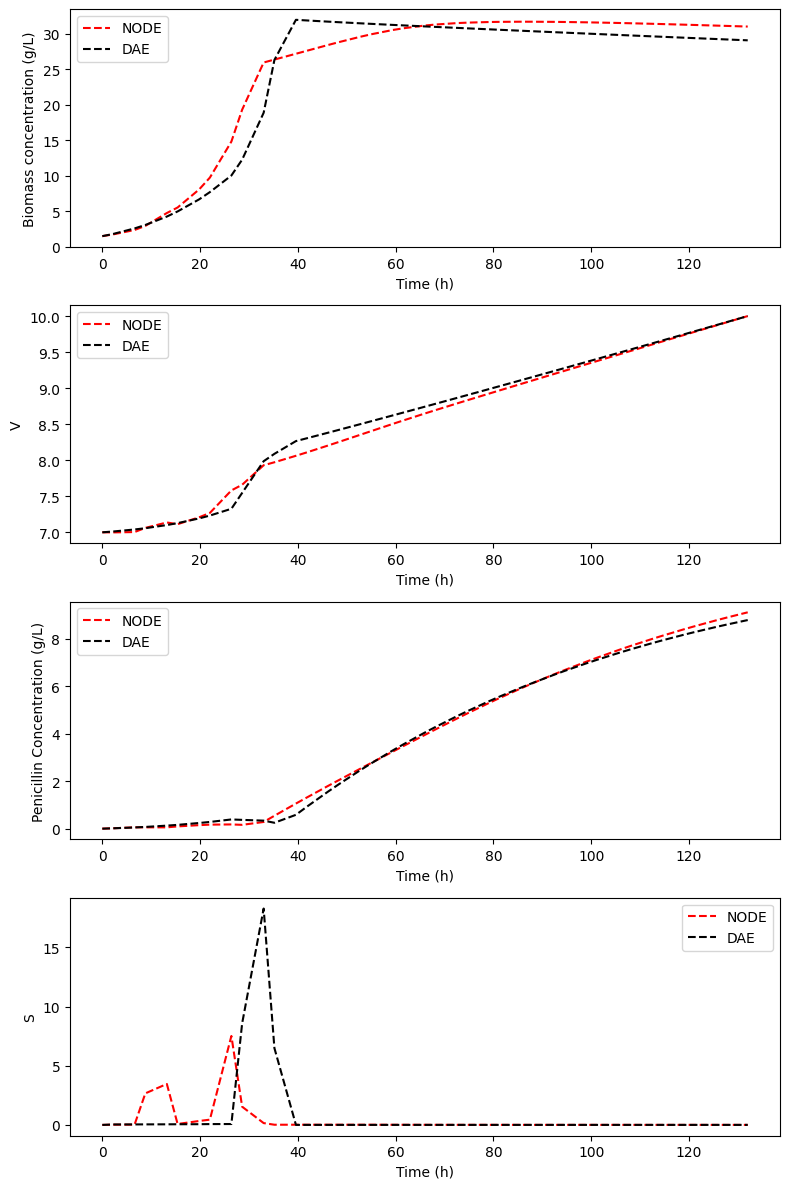

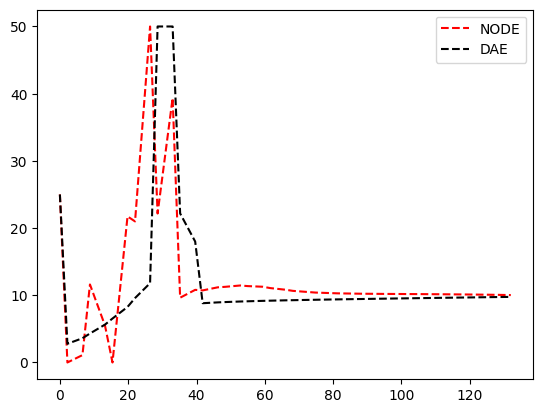

In [38]:
fig, axs = plt.subplots(4, 1, figsize=(8, 12))

# Plot X
axs[0].plot(t, x1,'r--' ,label='NODE')
axs[0].plot(t, x1_t,'k--' ,label='DAE')
axs[0].set_xlabel('Time (h)')
axs[0].set_ylabel('Biomass concentration (g/L)')
axs[0].legend()
#axs[0].set_title('X Profile')

# Plot V
axs[1].plot(t, x4,'r--', label='NODE')
axs[1].plot(t, x4_t,'k--' ,label='DAE')
axs[1].set_xlabel('Time (h)')
axs[1].set_ylabel('V')
axs[1].legend()
#axs[1].set_title('V Profile')

# Plot P
axs[2].plot(t, x2,'r--' ,label='NODE')
axs[2].plot(t, x2_t,'k--' ,label='DAE')
axs[2].set_xlabel('Time (h)')
axs[2].set_ylabel('Penicillin Concentration (g/L)')
axs[2].legend()
#axs[2].set_title('P Profile')

# Plot S
axs[3].plot(t, x3,'r--', label='NODE')
axs[3].plot(t, x3_t,'k--' ,label='DAE')
axs[3].set_xlabel('Time (h)')
axs[3].set_ylabel('S')
axs[3].legend()
#axs[3].set_title('S Profile')
plt.savefig('CS3_dS_80k_State.png', dpi=300)
# Adjust the spacing between subplots
plt.tight_layout()

# Show the plots
plt.show()
plt.plot(t, u,'r--',label='NODE')
plt.plot(t, u_t,'k--' ,label='DAE')
plt.legend()
plt.savefig('CS3_dS_80k_Control.png', dpi=300)
plt.show()

In [ ]:
!pip install pysindy

     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 121.0/121.0 kB 1.9 MB/s eta 0:00:00


In [ ]:
import pysindy as ps
from sklearn.linear_model import LassoCV, Lasso

feature_library=ps.PolynomialLibrary(degree=2)

optimizer = ps.STLSQ(threshold=0.0001)
#optimizer = Lasso(alpha=75e-2, max_iter=25000, fit_intercept=False)
#optimizer = ps.SR3(threshold=10e-2, nu=0.5)
model = ps.SINDy(feature_library=feature_library,
                 optimizer=optimizer,
                 feature_names=["X", "V", "S", "P","U"])

model.fit(x=X_train[:,0:4], x_dot=Y_train,u=X_train[:,4].reshape(-1,1))

SINDy(differentiation_method=FiniteDifference(axis=-2),
      feature_library=PolynomialLibrary(),
      feature_names=['X', 'V', 'S', 'P', 'U'],
      optimizer=STLSQ(threshold=0.0001))

In [ ]:
n_features = feature_library.n_output_features_
print(f"Features ({n_features}):", feature_library.get_feature_names())

Features (21): ['1', 'x0', 'x1', 'x2', 'x3', 'x4', 'x0^2', 'x0 x1', 'x0 x2', 'x0 x3', 'x0 x4', 'x1^2', 'x1 x2', 'x1 x3', 'x1 x4', 'x2^2', 'x2 x3', 'x2 x4', 'x3^2', 'x3 x4', 'x4^2']


In [ ]:
model.print()

(X)' = 0.111 1 + 0.086 X + -0.036 V + 0.088 P + -0.008 U + 0.001 X V + 0.002 X P + 0.001 V^2 + 0.001 V S + -0.002 V P + 0.001 V U + -0.001 S^2 + -0.005 P^2
(V)' = 0.002 U
(S)' = 0.009 1 + 0.006 V + -0.016 S + -0.004 P + -0.002 U + -0.001 V^2 + 0.001 V S
(P)' = 2.850 1 + -0.226 X + -0.634 V + 0.001 S + -0.192 P + 0.249 U + -0.001 X V + -0.003 X P + 0.039 V^2 + -0.001 V S + 0.006 V P + -0.015 V U + 0.001 S^2 + 0.011 P^2
